In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv

import draw

In [2]:
Basedir = r"C:\repos\EngNaval-Poli-USP\Mecânica de Estruturas II\Projeto Final\Abaqus modeling"

# Read inputs csv file
with open(os.path.join(Basedir, "inputs.csv"), 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=',')
    linhas = list(reader)


R_canto = float(linhas[1][1])
H_fundo = float(linhas[2][1])
H1 = float(linhas[3][1])
H2 = float(linhas[4][1])
H3 = float(linhas[5][1])
H4 = float(linhas[6][1])
B1 = float(linhas[7][1])
B2 = float(linhas[8][1])
B_cost = float(linhas[9][1])
Comprimento_SM = float(linhas[10][1])

Material = linhas[0][5]  # "Steel"
Young_Mod = float(linhas[1][5])
Poisson = float(linhas[2][5])
Densidade = float(linhas[3][5])

Ref_T = [float(linhas[12][1]), float(linhas[12][2])]  # 0.2 and 0.07
Ref_L = [float(linhas[13][1]), float(linhas[13][2])]  # 0.25 and 0.1

# Print all variables to verify
print("="*60)
print("MAPPED VARIABLES FROM CSV")
print("="*60)
print(f"R_cantos: {R_canto}")
print(f"H_fundo: {H_fundo}")
print(f"H1: {H1}")
print(f"H2: {H2}")
print(f"H3: {H3}")
print(f"H4: {H4}")
print(f"B1: {B1}")
print(f"B2: {B2}")
print(f"Comprimento_SM: {Comprimento_SM}")
print(f"Material: {Material}")
print(f"Young_Mod: {Young_Mod}")
print(f"Poisson: {Poisson}")
print(f"Densidade: {Densidade}")
print(f"Ref_T: {Ref_T}")
print(f"Ref_L: {Ref_L}")

MAPPED VARIABLES FROM CSV
R_cantos: 5.0
H_fundo: 3.84
H1: 3.84
H2: 5.15
H3: 5.14
H4: 5.14
B1: 15.0
B2: 4.38
Comprimento_SM: 31.0
Material: Steel
Young_Mod: 206000000000.0
Poisson: 0.3
Densidade: 7800.0
Ref_T: [0.6, 0.3]
Ref_L: [0.6, 0.18]


In [3]:
# utils
Ht = R_canto + H1 + H2 + H3 + H4
Bt = R_canto + B1 + B2

In [4]:
points = [
    (0.0, 0.0),
    (0.0, H_fundo),
    (0.0, Ht),
    (B1, 0.0),
    (B2, 0.0),
    (B1, H_fundo),
    (Bt-B_cost, R_canto+H1),
]

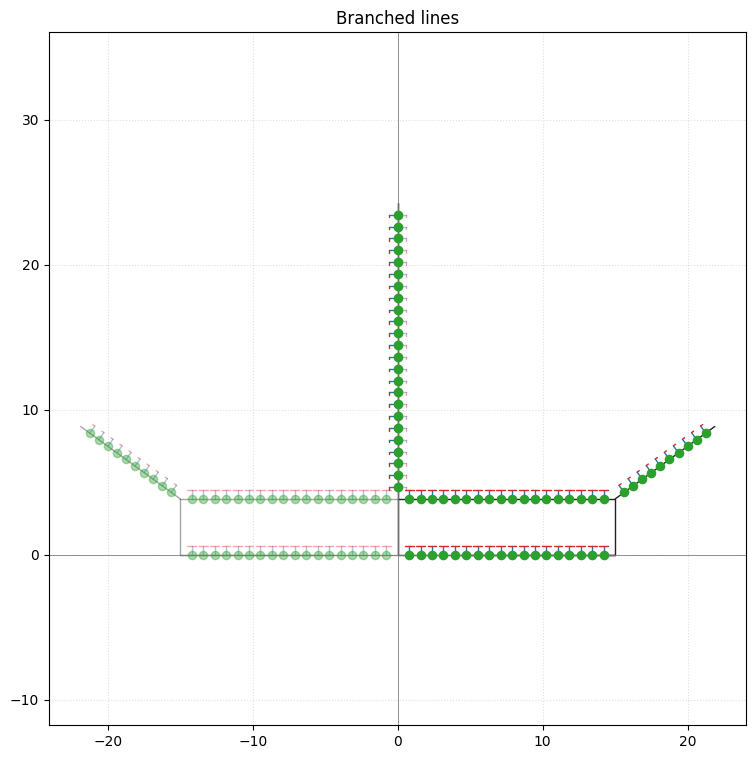

In [5]:
segments = [
    (points[0], points[1], 0, "T"),
    (points[1], points[2], 24, "L1"),
    (points[0], points[3], 18, "T"),
    (points[3], points[4], 0, "L2"),
    (points[3], points[5], 0, "L2"),
    (points[1], points[5], 18, "T"),
    (points[5], points[6], 10, "L2"),
]
results = draw.draw_segments(segments)